Memproses database...
- astronaut diproses
- camera diproses
- coffee diproses
- coins diproses
- chelsea diproses

Hasil Retrieval (Mean RGB + L2):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


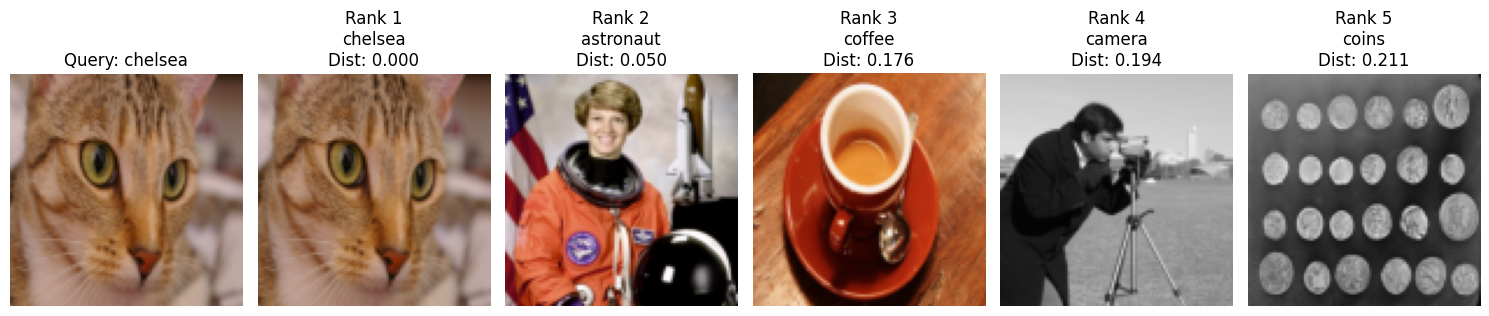

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# Fungsi fitur mean RGB (3 dimensi)
def calculate_mean_rgb(image):
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])


# 1. Dataset citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database...")

for name in image_db_names:
    img = getattr(data, name)()

    # Pastikan RGB
    if img.ndim == 2:
        img = color.gray2rgb(img)

    # Resize biar konsisten
    img = transform.resize(img, (100, 100), anti_aliasing=True)

    database_images.append(img)
    database_features.append(calculate_mean_rgb(img))

    print(f"- {name} diproses")


# 2. Pilih query
query_name = "chelsea"
query_index = image_db_names.index(query_name)

query_image = database_images[query_index]
query_feature = database_features[query_index]


# 3. Hitung jarak Euclidean (L2)
distances = []
for feat in database_features:
    dist = distance.euclidean(query_feature, feat)
    distances.append(dist)


# 4. Urutkan hasil
sorted_indices = np.argsort(distances)

print("\nHasil Retrieval (Mean RGB + L2):")

# 5. Visualisasi
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))

# Query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_name}")
axes[0].axis("off")

# Hasil ranking
for i, idx in enumerate(sorted_indices):
    ax = axes[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis("off")

    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Max NCC Original: 1.0000
Max NCC Rotated: 0.6059
Max NCC Scaled: 0.6072


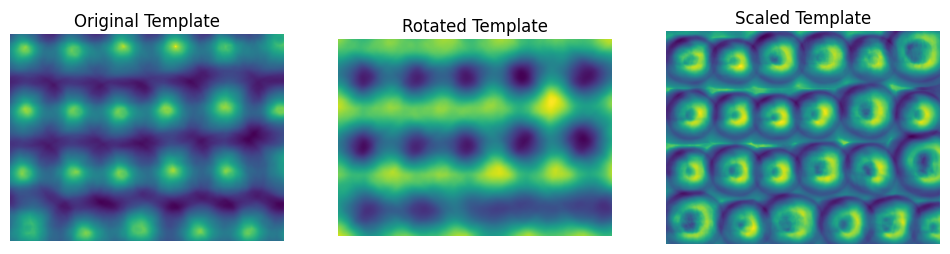

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

# 1. Load image
image = data.coins()

# Template asli
template = image[15:80, 190:260]

# 2. Modifikasi template
template_rotated = rotate(template, angle=45, resize=True)
template_scaled = rescale(template, 0.5, anti_aliasing=True)

# 3. Matching
result_original = match_template(image, template)
result_rotated = match_template(image, template_rotated)
result_scaled = match_template(image, template_scaled)

# 4. Ambil nilai maksimum
max_orig = np.max(result_original)
max_rot = np.max(result_rotated)
max_scale = np.max(result_scaled)

print(f"Max NCC Original: {max_orig:.4f}")
print(f"Max NCC Rotated: {max_rot:.4f}")
print(f"Max NCC Scaled: {max_scale:.4f}")

# 5. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(result_original, cmap='viridis')
ax[0].set_title("Original Template")

ax[1].imshow(result_rotated, cmap='viridis')
ax[1].set_title("Rotated Template")

ax[2].imshow(result_scaled, cmap='viridis')
ax[2].set_title("Scaled Template")

for a in ax:
    a.axis('off')

plt.show()